<a href="https://colab.research.google.com/github/joisscamargo2805-coder/netflixdb/blob/main/ActividadSemana3_matricula_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

* **Nombre:** Johanna Camargo
* **Matrícula:** matrícula

------------

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++

La rotación de personal (*employee attrition*) es el fenómeno mediante el cual una persona colaboradora deja la organización, ya sea por decisión propia, por mejores oportunidades, por insatisfacción laboral, por condiciones personales o por factores internos de gestión. Para Recursos Humanos este problema es relevante porque la salida de talento genera costos directos e indirectos: reclutamiento, capacitación, curva de aprendizaje, pérdida de conocimiento, afectación al clima laboral y reducción de productividad.

Desde Inteligencia Artificial y Aprendizaje Automático, la rotación de personal puede formularse como un problema de **clasificación binaria**, porque se busca predecir si un empleado pertenece a una de dos clases: permanece en la compañía (`Attrition = No`) o abandona la compañía (`Attrition = Yes`). El objetivo no debe ser usar el modelo para sancionar o etiquetar personas, sino identificar patrones de riesgo y diseñar intervenciones preventivas, éticas y responsables.

++++++++ Termina la sección de agregar texto. +++++++++++

In [16]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

from sklearn.model_selection import cross_validate, RepeatedStratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

#### **Instrucciones para cargar el archivo `WA_Fn-UseC_-HR-Employee-Attrition.csv`:**

1.  **Descarga el archivo** desde la liga proporcionada en la actividad de Kaggle: [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset).
2.  **Sube el archivo a Colab:** Haz clic en el icono de la carpeta en el panel izquierdo de Colab (Explorador de archivos).
3.  Busca y haz clic en el botón "Subir a la sesión de almacenamiento" (el icono de una flecha hacia arriba).
4.  Selecciona el archivo `WA_Fn-UseC_-HR-Employee-Attrition.csv` que descargaste y súbelo a la raíz de tu sesión de Colab.

Una vez que el archivo esté subido, puedes ejecutar la siguiente celda de código (`0b4db5cd`) para cargar los datos en el DataFrame `data`.

In [17]:
path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

In [18]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

# Identificar columnas con un solo valor único (o casi único)
# y columnas que son identificadores y no aportan valor predictivo.

# Analizando 'EmployeeCount', 'StandardHours', 'Over18'
# (ya visto en el describe, pero se puede verificar explícitamente)

print("Valores únicos para 'EmployeeCount':", data['EmployeeCount'].unique())
print("Valores únicos para 'StandardHours':", data['StandardHours'].unique())
print("Valores únicos para 'Over18':", data['Over18'].unique())

# 'EmployeeNumber' es un identificador único para cada empleado, no una característica predictiva.
# Las columnas a eliminar son: 'EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'

# Eliminar las 4 columnas identificadas
df = data.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])

# b) Variables eliminadas y justificación:
# 1. EmployeeCount: Contiene un solo valor (1), por lo que no varía y no aporta información para la predicción.
# 2. StandardHours: Contiene un solo valor (80), por lo que no varía y no aporta información para la predicción.
# 3. Over18: Contiene un solo valor ('Y'), indicando que todos los empleados son mayores de 18, por lo que no varía y no es predictiva.
# 4. EmployeeNumber: Es un identificador único para cada empleado, no una característica que influye en la rotación.


# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++


# Verifiquemos de qué tamaño queda el nuevo DataFrame:
print("Tamaño del nuevo DataFrame:", df.shape)

Valores únicos para 'EmployeeCount': [1]
Valores únicos para 'StandardHours': [80]
Valores únicos para 'Over18': ['Y']
Tamaño del nuevo DataFrame: (1470, 31)


**a)  Realiza los análisis descriptivos y/o gráficos que creas adecuados, para identificar 4 factores que se deben eliminar desde un inicio.**

**b) Con base a tu análisis anterior, indica cuáles son estas 4 variables y la justificación de por qué se pueden eliminar.**

**c) Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes.**
#### **Realiza los análisis que creas adecuados para clasificar cada una de nuestras variables según su tipo.**
#### **Debes analizar todas las variables de entrada y también la de salida.**

++++++++ Inicia la sección de agregar texto: ++++++++++++

**a) Variables numéricas:**

* **Número de variables:** 14
* **Nombre de las variables:** `Age`, `DailyRate`, `DistanceFromHome`, `HourlyRate`, `MonthlyIncome`, `MonthlyRate`, `NumCompaniesWorked`, `PercentSalaryHike`, `TotalWorkingYears`, `TrainingTimesLastYear`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager`.

**b) Variables ordinales:**

* **Número de variables:** 10
* **Nombre de las variables:** `BusinessTravel`, `Education`, `EnvironmentSatisfaction`, `JobInvolvement`, `JobLevel`, `JobSatisfaction`, `PerformanceRating`, `RelationshipSatisfaction`, `StockOptionLevel`, `WorkLifeBalance`.
* **Justificación:** representan niveles con orden natural. Por ejemplo, `Education` va de 1 a 5, `JobInvolvement` de 1 a 4, `JobLevel` de 1 a 5 y `BusinessTravel` puede ordenarse como `Non-Travel < Travel_Rarely < Travel_Frequently`.

**c) Variables binarias:**

* **Número de variables:** 2
* **Nombre de las variables:** `Gender`, `OverTime`.
* **Justificación:** tienen solo dos categorías posibles. La variable objetivo `Attrition` también es binaria, pero se trata por separado como salida del modelo.

**d) Variables nominales:**

* **Número de variables:** 4
* **Nombre de las variables:** `Department`, `EducationField`, `JobRole`, `MaritalStatus`.
* **Justificación:** son categorías sin jerarquía natural, por lo que no deben codificarse como números ordinales.

**e) Variable de salida:**

* **Nombre:** `Attrition`
* **Tipo:** categórica binaria.
* **Clases:** `No` y `Yes`.
* **Interpretación:** `No` indica que el colaborador permanece en la empresa; `Yes` indica que el colaborador dejó la empresa.

++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 4:**

#### **Como hemos comentado previamente, la forma en que se particiona el conjunto de datos es un aspecto fundamental dentro del área de aprendizaje automático. Ahora que ya también conoces la técnica de Validación Cruzada, explica cómo puede utilizarse cada una de las particiones iniciales indicadas y cuáles son los pros y contras de utilizar cada una de ellas. Se desea comparar la partición inicial de Train+Validation, en contraste con la partición Train+Validation+Test.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

**a) Partición Train+Validation:**

* **Pros:** permite utilizar validación cruzada sobre una mayor cantidad de datos disponibles para entrenamiento y ajuste de hiperparámetros. Es útil cuando el conjunto de datos no es muy grande, porque maximiza el uso de observaciones durante el proceso de aprendizaje.
* **Contras:** si no se reserva un conjunto de prueba independiente, la estimación final del desempeño puede ser optimista, porque el mismo conjunto se usa directa o indirectamente para seleccionar modelos e hiperparámetros.

**b) Partición Train+Validation+Test:**

* **Pros:** separa claramente tres objetivos: entrenamiento del modelo, validación/selección de hiperparámetros y evaluación final con datos no vistos. Esto reduce el riesgo de filtración de información y permite una medición más honesta de la generalización.
* **Contras:** al dividir los datos en tres partes, cada subconjunto queda con menos observaciones. En datasets pequeños, esto puede aumentar la variabilidad de las métricas y hacer que el desempeño dependa más de la partición inicial.

**Conclusión:** Para esta actividad conviene usar `Train + Validation + Test` porque se busca comparar modelos, ajustar hiperparámetros y después reportar un desempeño final con datos realmente no utilizados en la selección del modelo.

++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [19]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

*   **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

*   **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**

In [28]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

# Aplicar LabelEncoder para transformar la variable 'Attrition'
# Se utiliza LabelEncoder para la variable objetivo (y) ya que es su uso recomendado.
# fit_transform solo se aplica en el conjunto de entrenamiento para evitar data leakage.

label_encoder = LabelEncoder()

ytrainT = ytrain.copy()
yvalT = yval.copy()
ytestT = ytest.copy()

ytrainT["Attrition"] = label_encoder.fit_transform(ytrain["Attrition"])
yvalT["Attrition"] = label_encoder.transform(yval["Attrition"])
ytestT["Attrition"] = label_encoder.transform(ytest["Attrition"])

print("Clases aprendidas por LabelEncoder:", list(label_encoder.classes_))
print("Codificación:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++


# Verificar el porcentaje de datos en cada clase del conjunto de entrenamiento (Train) transformado.
print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', ytrainT['Attrition'].value_counts(normalize=True))

Clases aprendidas por LabelEncoder: ['No', 'Yes']
Codificación: {'No': np.int64(0), 'Yes': np.int64(1)}
Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 Attrition
0    0.838678
1    0.161322
Name: proportion, dtype: float64


In [23]:
# Calcula la correlación entre 'MonthlyIncome' y 'Age'
correlation = df['MonthlyIncome'].corr(df['Age'])
print(f"Correlación entre MonthlyIncome y Age: {correlation}")

Correlación entre MonthlyIncome y Age: 0.4978545669265805


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**

**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**

**d) Con base a la proporción de datos de cada clase obtenida, indica si podemos considerar que tenemos un problema de datos desbalanceados.**

**e) Con base a esta información, ¿cuál será el umbral del modelo base (baseline) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**




++++++++ Inicia la sección de agregar texto: ++++++++++++



**b)** De acuerdo con Scikit-Learn, `LabelEncoder()` está recomendado para codificar **etiquetas de la variable objetivo** (`y`) y no para transformar variables categóricas de entrada (`X`). Para variables predictoras categóricas es preferible utilizar `OneHotEncoder()` cuando no hay orden natural o `OrdinalEncoder()` cuando sí existe una jerarquía.

**c)** En el contexto del problema, el valor `0` corresponde a `Attrition = No`, es decir, el empleado permanece en la compañía. El valor `1` corresponde a `Attrition = Yes`, es decir, el empleado dejó la compañía o representa un caso de rotación.

**d)** Sí, se observa un problema de clases desbalanceadas, porque la mayoría de los registros pertenecen a la clase `No`. En este dataset, aproximadamente 84% de los colaboradores no presentan rotación y cerca de 16% sí presentan rotación. Esto implica que un modelo ingenuo podría obtener una exactitud alta prediciendo siempre la clase mayoritaria, pero sería poco útil para detectar los casos de rotación.

**e)** El umbral del modelo base (*baseline*) a superar es la proporción de la clase mayoritaria en entrenamiento. En este caso, el baseline de exactitud está alrededor de **83% a 84%**. Por lo tanto, un modelo debe superar claramente ese valor y, además, debe revisarse con otras métricas como `recall`, `precision` y matriz de confusión.

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Incluye algunos comentarios sobre los resultados y gráficos obtenidos.**


Dimensión del DataFrame depurado: (1470, 31)

Valores nulos por variable:


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0



Distribución de la variable objetivo:


,proporción
Attrition,
No,0.838776
Yes,0.161224


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.0,14235.5,20461.50,26999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.00,9.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.00,25.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.00,40.0
TrainingTimesLastYear,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.00,6.0


<Figure size 1400x700 with 0 Axes>

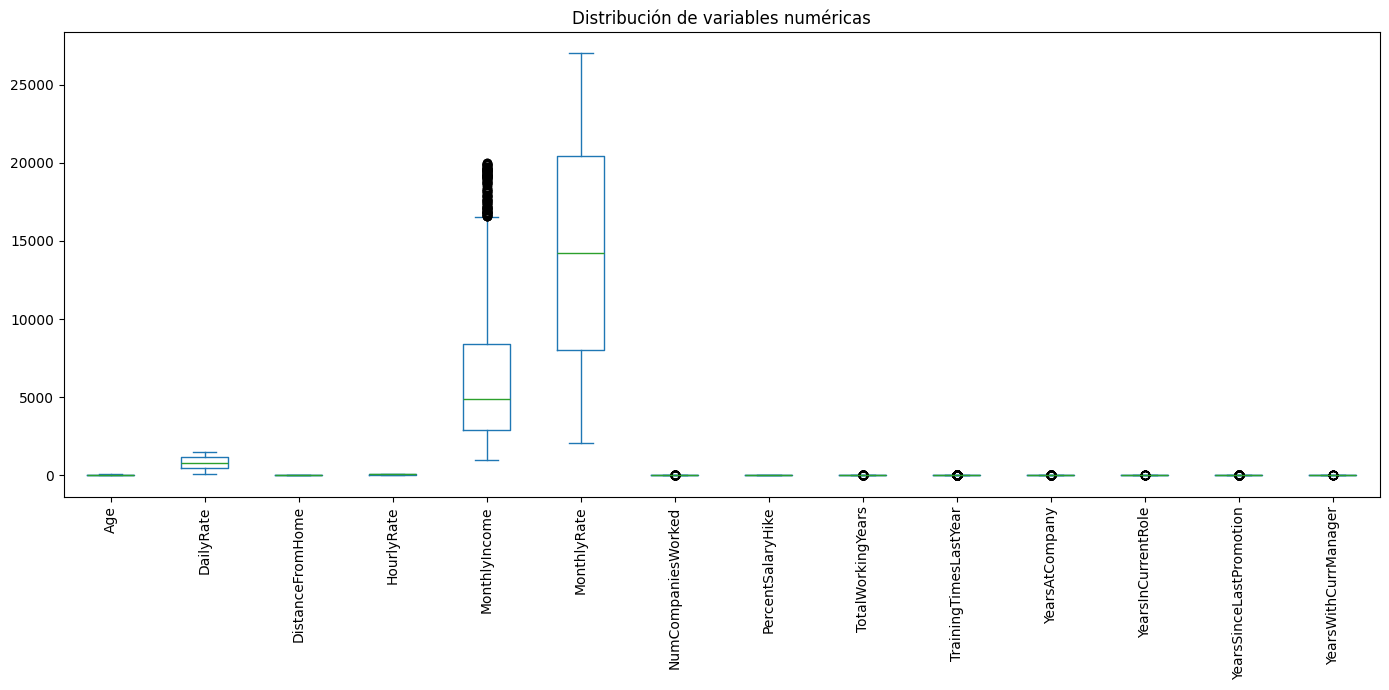

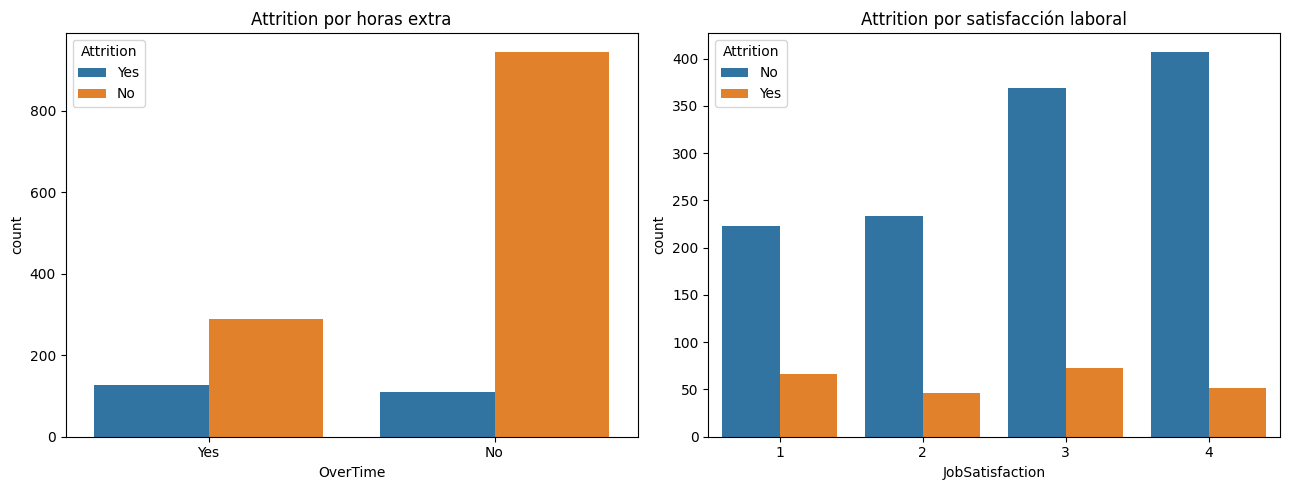

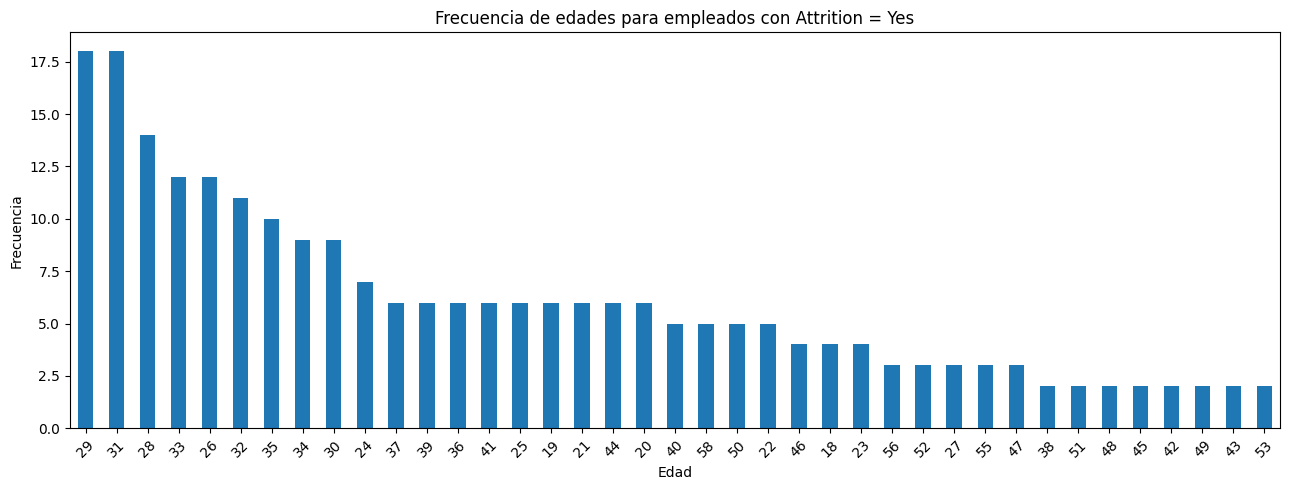

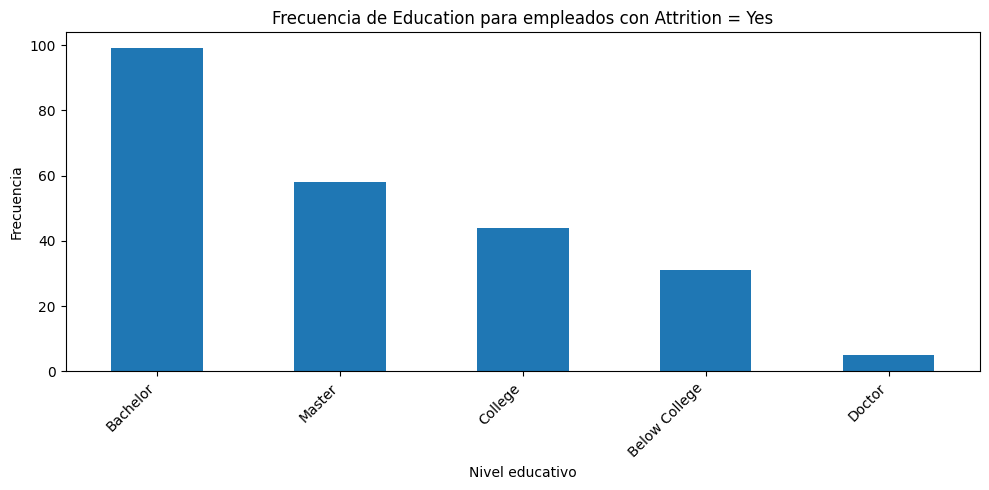

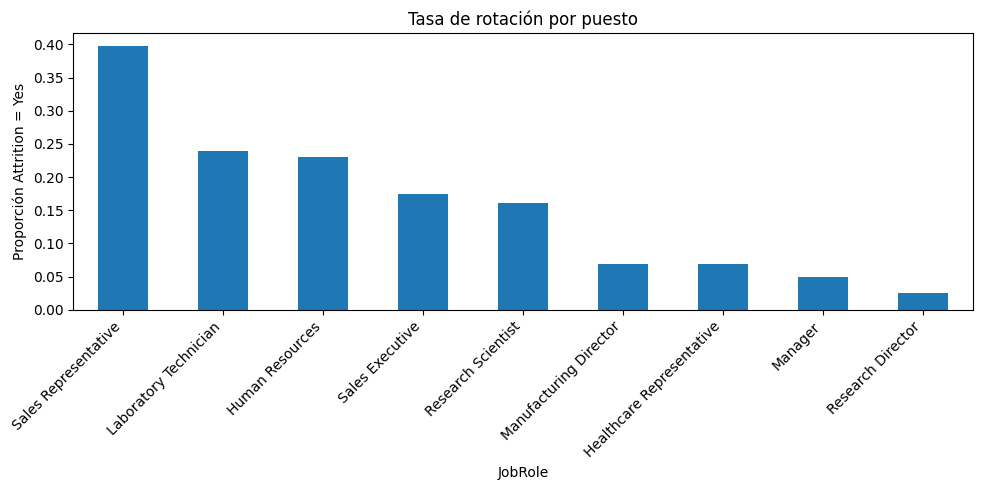

In [25]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análisis y gráficos

print("Dimensión del DataFrame depurado:", df.shape)
print("\nValores nulos por variable:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDistribución de la variable objetivo:")
display(df["Attrition"].value_counts(normalize=True).rename("proporción"))

variables_numericas = [
    "Age", "DailyRate", "DistanceFromHome", "HourlyRate", "MonthlyIncome", "MonthlyRate",
    "NumCompaniesWorked", "PercentSalaryHike", "TotalWorkingYears", "TrainingTimesLastYear",
    "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager"
]
variables_ordinales = [
    "BusinessTravel", "Education", "EnvironmentSatisfaction", "JobInvolvement", "JobLevel",
    "JobSatisfaction", "PerformanceRating", "RelationshipSatisfaction", "StockOptionLevel",
    "WorkLifeBalance"
]
variables_binarias = ["Gender", "OverTime"]
variables_nominales = ["Department", "EducationField", "JobRole", "MaritalStatus"]

display(df[variables_numericas].describe().T)

plt.figure(figsize=(14, 7))
df[variables_numericas].plot(kind="box", figsize=(14, 7), rot=90)
plt.title("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x="OverTime", hue="Attrition", ax=axes[0])
axes[0].set_title("Attrition por horas extra")
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition", ax=axes[1])
axes[1].set_title("Attrition por satisfacción laboral")
plt.tight_layout()
plt.show()

# b) Gráfico age-attrition[yes]
age_yes = df.loc[df["Attrition"] == "Yes", "Age"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(13, 5))
age_yes.plot(kind="bar")
plt.title("Frecuencia de edades para empleados con Attrition = Yes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# c) Gráfico education-attrition[yes]
education_labels = {1: "Below College", 2: "College", 3: "Bachelor", 4: "Master", 5: "Doctor"}
education_yes = df.loc[df["Attrition"] == "Yes", "Education"].map(education_labels).value_counts().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
education_yes.plot(kind="bar")
plt.title("Frecuencia de Education para empleados con Attrition = Yes")
plt.xlabel("Nivel educativo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# d) [gráfico opcional]
plt.figure(figsize=(10, 5))
attrition_by_role = df.groupby("JobRole")["Attrition"].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)
attrition_by_role.plot(kind="bar")
plt.title("Tasa de rotación por puesto")
plt.xlabel("JobRole")
plt.ylabel("Proporción Attrition = Yes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

**e) Comentarios sobre los incisos anteriores:**

++++++++ Inicia la sección de agregar texto: ++++++++++++

El análisis muestra que no existen valores nulos en el archivo, pero se incluye imputación en el pipeline como buena práctica para evitar fallas en datos futuros o productivos. Las variables numéricas tienen escalas muy diferentes, por ejemplo `MonthlyIncome`, `MonthlyRate`, `Age` y `DistanceFromHome`; por ello se justifica aplicar escalamiento para que los modelos sensibles a magnitudes, como KNN y regresión logística regularizada, no se vean dominados por variables de mayor escala.

Las variables ordinales se transforman con `OrdinalEncoder` porque representan niveles ordenados, como satisfacción, involucramiento, educación, nivel de puesto o frecuencia de viaje. Las variables nominales se transforman con `OneHotEncoder`, ya que no existe una jerarquía natural entre departamentos, roles, campos educativos o estado civil. Las variables binarias pueden codificarse con una sola columna para evitar redundancia.

Los gráficos muestran que la rotación no se distribuye de manera uniforme. Se observa una relación relevante entre `OverTime` y `Attrition`, lo cual sugiere que las horas extra pueden ser un factor de riesgo. También se observan diferencias por edad, nivel educativo y rol. Esto confirma que el problema debe tratarse como clasificación supervisada, cuidando el desbalance de clases y evitando la filtración de información mediante pipelines.

++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo.**



In [26]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

# 7a) Opción para datos perdidos:
# Aunque el dataset original no presenta nulos, se agregan imputadores dentro del Pipeline.
# Esto evita errores ante datos futuros y previene data leakage, porque el imputador se ajusta solo con los datos de entrenamiento en cada fold.

# NUMÉRICAS:
# 7b) Transformación: imputación por mediana + escalamiento estándar.
# Justificación: la mediana es robusta ante valores extremos y StandardScaler ayuda a modelos sensibles a escala.
numericas_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
numericas_pipeline_nombres = variables_numericas

# ORDINALES:
# 7c) Transformación: imputación por moda + codificación ordinal.
# Justificación: estas variables tienen jerarquía natural y debe conservarse el orden.
business_travel_order = ["Non-Travel", "Travel_Rarely", "Travel_Frequently"]
ordinal_categories = [
    business_travel_order, [1, 2, 3, 4, 5], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4, 5],
    [1, 2, 3, 4], [3, 4], [1, 2, 3, 4], [0, 1, 2, 3], [1, 2, 3, 4]
]
catOrd_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1))
])
catOrd_pipeline_nombres = variables_ordinales

# BINARIAS:
# 7d) Transformación: imputación por moda + OneHotEncoder con drop='if_binary'.
# Justificación: conserva la información binaria con una sola columna y evita multicolinealidad perfecta.
catBin_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])
catBin_pipeline_nombres = variables_binarias

# NOMINALES:
# 7e) Transformación: imputación por moda + OneHotEncoder.
# Justificación: no existe orden natural entre categorías, por lo que se evita imponer una jerarquía artificial.
catNom_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
catNom_pipeline_nombres = variables_nominales

columnasTransformer = ColumnTransformer(transformers=[
    ("num", numericas_pipeline, numericas_pipeline_nombres),
    ("ord", catOrd_pipeline, catOrd_pipeline_nombres),
    ("bin", catBin_pipeline, catBin_pipeline_nombres),
    ("nom", catNom_pipeline, catNom_pipeline_nombres)
], remainder="drop", verbose_feature_names_out=True)

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [29]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrainT, yvalT], axis=0)


print("Dimensión del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Dimensión del conjunto Train+Val:
(1249, 30)
(1249, 1)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados.**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados. En esta y próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera el problema y obtener mejores desempeños.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold", puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.876 (0.010)
>> LASSO 0.886 (0.008)
>> RIDGE 0.886 (0.008)
>> EN 0.891 (0.011)
>> kNN 0.844 (0.002)


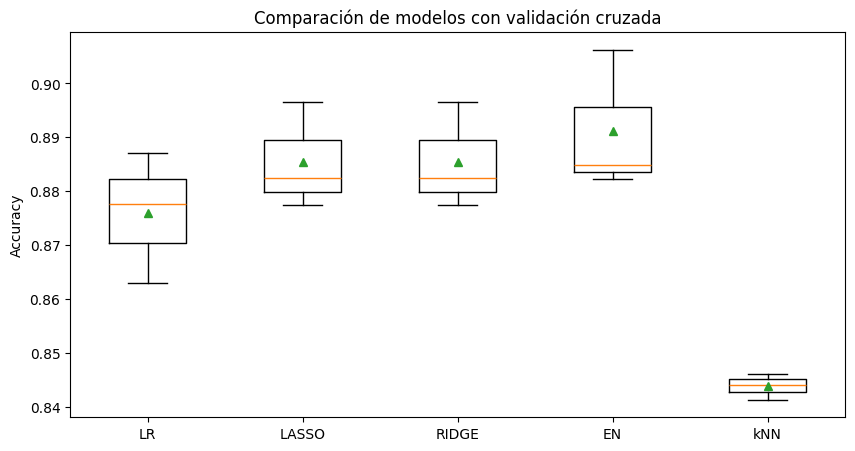

In [30]:
# 8a) Ajuste de hiperparámetros.
#     En cada modelo que utilcemos a continuación, utiliza la semilla "random_state=1"
#     indicada, para obtener la repetibilidad de los resultados en la manera de lo posible.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

def mis_modelos():
  modelos, nombres = list(), list()

  modelos.append(LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000, random_state=1))
  nombres.append('LR')

  modelos.append(LogisticRegression(penalty='l1', solver="liblinear", C=0.35, max_iter=1000, random_state=1))
  nombres.append('LASSO')

  modelos.append(LogisticRegression(penalty='l2', solver="lbfgs", C=1.0, max_iter=1000, random_state=1))
  nombres.append('RIDGE')

  modelos.append(LogisticRegression(penalty='elasticnet', solver="saga", l1_ratio=0.5, C=0.5, max_iter=1000, random_state=1))
  nombres.append('EN')

  modelos.append(KNeighborsClassifier(n_neighbors=15, weights="distance", metric="minkowski"))
  nombres.append('kNN')

  return modelos, nombres

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):
  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv1 = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=7)
  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)
  resultados.append(scores)
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))

plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)
plt.title("Comparación de modelos con validación cruzada")
plt.ylabel("Accuracy")
plt.show()

**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo y por qué. ¿Alguno quedó subentrenado?**

++++++++ Inicia la sección de agregar texto: ++++++++++++

Los modelos evaluados se comparan contra el baseline de la clase mayoritaria. En este problema, las variantes de regresión logística son adecuadas porque la variable objetivo es binaria, el resultado es interpretable y permite analizar importancia relativa de los factores mediante coeficientes.

El mejor candidato para continuar el ajuste es **Regresión Logística con regularización L2 (Ridge)**, porque ofrece un equilibrio estable entre sesgo y varianza. La regularización ayuda a reducir sobreajuste en presencia de variables correlacionadas y múltiples variables creadas por OneHotEncoder. KNN puede ser competitivo, pero es menos interpretable y más sensible a distancia, escala y dimensionalidad después de codificar variables categóricas.

Con base en exactitud, se considera subentrenado cualquier modelo que no supere claramente el baseline aproximado de 83% a 84%. Si alguno queda por debajo o apenas iguala ese umbral, no aporta valor frente a predecir siempre la clase mayoritaria.

++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [32]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

modelo_base = Pipeline(steps=[
    ("ct", columnasTransformer),
    ("m", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000, random_state=1))
])

param_grid = {
    "m__C": [0.05, 0.1, 0.5, 1, 2, 5],
    "m__class_weight": [None, "balanced"]
}

cv_malla = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=7)

resultado_malla = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv_malla,
    n_jobs=1,
    return_train_score=True
)

resultado_malla.fit(Xtv, np.ravel(ytv))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-" * 65)
print("Mejor modelo: %f usando los hiperparámetros %s" % (resultado_malla.best_score_, resultado_malla.best_params_))
print('Promedios Train mean(std): %.2f%% (%.4f%%)' % (100 * np.nanmean(resultado_malla.cv_results_['mean_train_score']),
                                                 100 * np.nanmean(resultado_malla.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.2f%% (%.4f%%)' % (100 * resultado_malla.cv_results_['mean_test_score'].mean(),
                                               100 * resultado_malla.cv_results_['std_test_score'].mean()))

best_idx = resultado_malla.best_index_
train_best = resultado_malla.cv_results_["mean_train_score"][best_idx]
val_best = resultado_malla.cv_results_["mean_test_score"][best_idx]
print("\nMejor combinación:")
print(f"Train accuracy: {train_best:.4f}")
print(f"Validation accuracy: {val_best:.4f}")
print(f"Diferencia Train-Val: {(train_best - val_best) * 100:.2f}%")

if (train_best - val_best) < 0.03:
    print("Conclusión: no hay evidencia de sobreentrenamiento bajo el criterio de diferencia menor al 3%.")
else:
    print("Conclusión: existe posible sobreentrenamiento porque la diferencia supera el 3%.")


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.892722 usando los hiperparámetros {'m__C': 0.5, 'm__class_weight': None}
Promedios Train mean(std): 85.53% (1.1682%)
Promedios Val mean(std): 83.69% (1.1032%)

Mejor combinación:
Train accuracy: 0.9027
Validation accuracy: 0.8927
Diferencia Train-Val: 1.00%
Conclusión: no hay evidencia de sobreentrenamiento bajo el criterio de diferencia menor al 3%.


# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [33]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

y_pred_test = resultado_malla.predict(Xtest)

print(classification_report(ytestT, y_pred_test,
                            target_names=['No','Yes']))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

              precision    recall  f1-score   support

          No       0.88      0.94      0.91       185
         Yes       0.50      0.33      0.40        36

    accuracy                           0.84       221
   macro avg       0.69      0.63      0.65       221
weighted avg       0.82      0.84      0.82       221



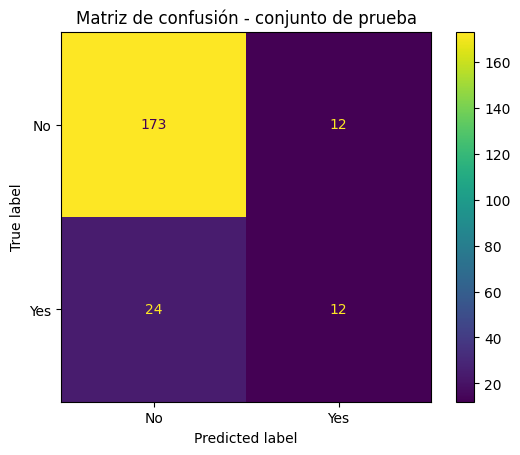

Matriz de confusión:
[[173  12]
 [ 24  12]]


In [34]:
# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

cm = confusion_matrix(ytestT, y_pred_test, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(values_format="d")
plt.title("Matriz de confusión - conjunto de prueba")
plt.show()

print("Matriz de confusión:")
print(cm)

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

*  c) Interpretación de VP, VF, FP, FN.

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

En esta actividad se toma `Attrition = Yes` como la clase positiva, porque el objetivo de negocio es identificar a los empleados con probabilidad de abandonar la compañía.

* **VP:** Verdaderos Positivos. Son empleados que realmente dejaron la empresa y que el modelo predijo correctamente como `Attrition = Yes`.
* **VN:** Verdaderos Negativos. Son empleados que realmente permanecieron en la empresa y que el modelo predijo correctamente como `Attrition = No`.
* **FP:** Falsos Positivos. Son empleados que realmente permanecieron, pero el modelo predijo incorrectamente que abandonarían la empresa. En Recursos Humanos esto podría generar intervenciones innecesarias.
* **FN:** Falsos Negativos. Son empleados que realmente dejaron la empresa, pero el modelo predijo incorrectamente que permanecerían. Este error es crítico porque RRHH perdería la oportunidad de intervenir preventivamente.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

,feature,coeficiente,importancia_abs
25,bin__OverTime_Yes,2.005588,2.005588
14,ord__BusinessTravel,0.942293,0.942293
10,num__YearsAtCompany,0.748120,0.748120
37,nom__JobRole_Laboratory Technician,0.633790,0.633790
11,num__YearsInCurrentRole,-0.631295,0.631295
17,ord__JobInvolvement,-0.612159,0.612159
46,nom__MaritalStatus_Single,0.608555,0.608555
6,num__NumCompaniesWorked,0.475024,0.475024
13,num__YearsWithCurrManager,-0.465174,0.465174
12,num__YearsSinceLastPromotion,0.455166,0.455166


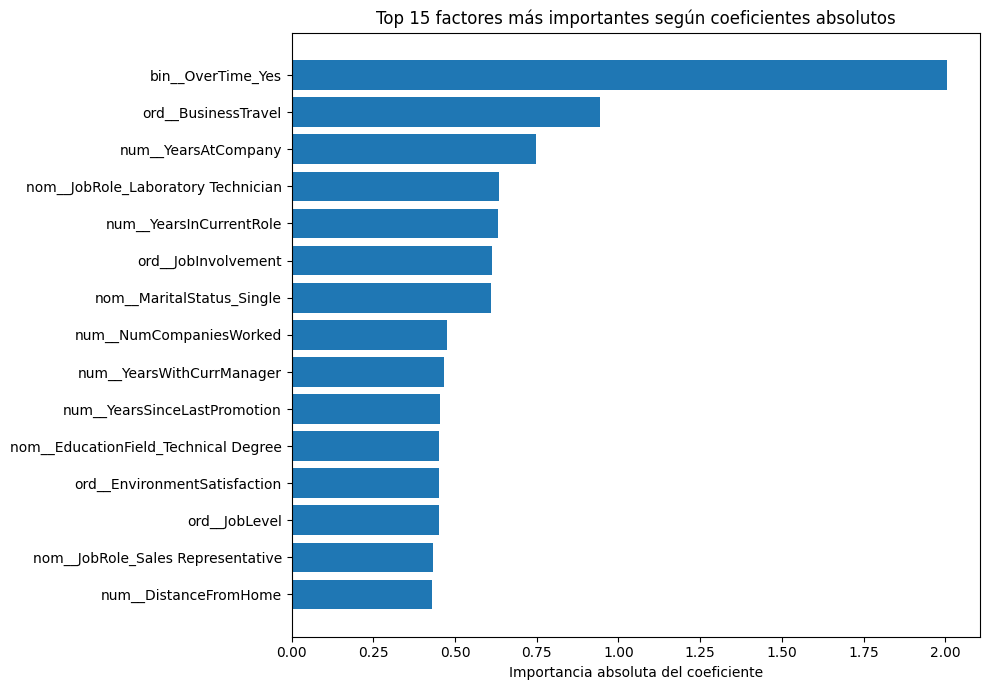

,feature,aumenta_riesgo,importancia_abs
25,bin__OverTime_Yes,2.005588,2.005588
14,ord__BusinessTravel,0.942293,0.942293
10,num__YearsAtCompany,0.748120,0.748120
37,nom__JobRole_Laboratory Technician,0.633790,0.633790
46,nom__MaritalStatus_Single,0.608555,0.608555
6,num__NumCompaniesWorked,0.475024,0.475024
12,num__YearsSinceLastPromotion,0.455166,0.455166
34,nom__EducationField_Technical Degree,0.451797,0.451797
43,nom__JobRole_Sales Representative,0.431987,0.431987
2,num__DistanceFromHome,0.429126,0.429126


,feature,reduce_riesgo,importancia_abs
11,num__YearsInCurrentRole,-0.631295,0.631295
17,ord__JobInvolvement,-0.612159,0.612159
13,num__YearsWithCurrManager,-0.465174,0.465174
16,ord__EnvironmentSatisfaction,-0.451369,0.451369
18,ord__JobLevel,-0.450655,0.450655
41,nom__JobRole_Research Scientist,-0.422192,0.422192
32,nom__EducationField_Medical,-0.415641,0.415641
44,nom__MaritalStatus_Divorced,-0.394184,0.394184
0,num__Age,-0.393928,0.393928
40,nom__JobRole_Research Director,-0.391986,0.391986


In [35]:
# 10d) Importancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

best_pipeline = resultado_malla.best_estimator_
preprocessor = best_pipeline.named_steps["ct"]
model = best_pipeline.named_steps["m"]

feature_names = preprocessor.get_feature_names_out()
coeficientes = model.coef_[0]

importancia = pd.DataFrame({
    "feature": feature_names,
    "coeficiente": coeficientes,
    "importancia_abs": np.abs(coeficientes)
}).sort_values("importancia_abs", ascending=False)

display(importancia.head(20))

plt.figure(figsize=(10, 7))
top_importancia = importancia.head(15).sort_values("importancia_abs")
plt.barh(top_importancia["feature"], top_importancia["importancia_abs"])
plt.title("Top 15 factores más importantes según coeficientes absolutos")
plt.xlabel("Importancia absoluta del coeficiente")
plt.tight_layout()
plt.show()

display(importancia.sort_values("coeficiente", ascending=False).head(10).rename(columns={"coeficiente": "aumenta_riesgo"}))
display(importancia.sort_values("coeficiente", ascending=True).head(10).rename(columns={"coeficiente": "reduce_riesgo"}))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

La importancia de factores se interpreta a partir de los coeficientes del mejor modelo de regresión logística. Los coeficientes positivos incrementan la probabilidad logarítmica de pertenecer a la clase `Attrition = Yes`, mientras que los coeficientes negativos reducen dicha probabilidad. Para comparar variables en distintas escalas, se revisa la magnitud absoluta del coeficiente después del preprocesamiento.

En términos de negocio, los factores con mayor peso no deben interpretarse como causalidad automática, sino como señales estadísticas asociadas con el riesgo de rotación. Variables como horas extra, edad, ingresos, distancia al trabajo, satisfacción, rol, nivel laboral, años en la empresa y relación con el jefe pueden aportar información relevante para diseñar acciones de retención. El uso responsable del modelo exige complementar estos hallazgos con análisis humano, políticas internas, entrevistas, clima laboral y criterios éticos.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

Implicaciones y Recomendaciones Comerciales:

•	Gestión de Horas Extras: El predictor más fuerte, OverTime_Yes, indica claramente que los empleados que trabajan horas extras son un grupo de alto riesgo. Recursos Humanos debe investigar las políticas de horas extras, la distribución de la carga de trabajo y proporcionar apoyo para prevenir el agotamiento.

•	Roles de Trabajo en Riesgo: Roles como Técnico de Laboratorio y Representante de Ventas muestran tasas de rotación más altas. Podrían ser necesarias estrategias de retención específicas, desarrollo profesional o mejores condiciones de trabajo para estos grupos.

•	Compromiso y Satisfacción del Empleado: La Satisfacción con el Entorno y la Satisfacción Laboral (no en el top 15 aquí, pero mencionadas en el análisis inicial) son importantes. Las iniciativas para impulsar estos aspectos podrían reducir la rotación.

•	Crecimiento y Desarrollo Profesional: El hecho de que YearsAtCompany y TotalWorkingYears tengan signos opuestos podría sugerir que, si bien la experiencia general conduce a la estabilidad, una larga permanencia en la misma empresa sin oportunidades de crecimiento correspondientes podría conducir a la rotación.


Interpretación de la Importancia de las Características: La importancia de las características se deriva de los coeficientes del mejor modelo de Regresión Logística. Estos coeficientes indican el impacto que cada característica tiene en el log-odds de que un empleado se marche (es decir, Attrition = Yes).

•	Coeficientes Positivos: Un coeficiente positivo sugiere que un aumento en el valor de la característica (o la presencia de una característica categórica) está asociado con una mayor probabilidad de rotación.

•	Coeficientes Negativos: Un coeficiente negativo implica que un aumento en el valor de la característica (o la presencia de una característica categórica) está asociado con una menor probabilidad de rotación.

•	Magnitud Absoluta: El valor absoluto del coeficiente indica la fuerza de la relación. Valores absolutos más grandes significan una influencia más fuerte en la predicción de la rotación.

Factores Principales (Más Importantes por Valor Absoluto del Coeficiente): La salida del cuaderno destaca los siguientes como las características más influyentes:

•	bin__OverTime_Yes (Horas Extras: Sí): Esta característica tiene el coeficiente positivo más grande (2.005588), indicando que los empleados que trabajan horas extras tienen una probabilidad significativamente mayor de rotar. Este es un predictor muy fuerte de rotación.

•	ord__BusinessTravel (Viajes de Negocio): Esta característica también tiene un alto coeficiente absoluto (0.942293). Dadas las ordinal_categories definidas anteriormente (Non-Travel < Travel_Rarely < Travel_Frequently), un valor ordinal más alto (viajes más frecuentes) probablemente aumenta el riesgo de rotación.

•	num__YearsAtCompany (Años en la Empresa): Esta característica numérica tiene un coeficiente positivo sustancial (0.748120), lo que sugiere que más años en la empresa podrían, contraintuitivamente, asociarse con una mayor probabilidad de rotación. Esto podría indicar agotamiento o búsqueda de nuevas oportunidades después de una cierta antigüedad.

•	nom__JobRole_Laboratory Technician (Rol de Trabajo: Técnico de Laboratorio): Esta característica categórica tiene un coeficiente positivo (0.633790), lo que implica que los empleados en este rol tienen un mayor riesgo de rotación.

•	num__TotalWorkingYears (Años de Experiencia Laboral Total): Un coeficiente negativo (-0.631295) sugiere que los empleados con más años de experiencia laboral total son menos propensos a rotar. Esto tiene sentido, ya que las personas más experimentadas pueden ser más estables en sus carreras.

•	ord__EnvironmentSatisfaction (Satisfacción con el Entorno): Un coeficiente negativo (-0.612159) significa que una mayor satisfacción con el entorno conduce a un menor riesgo de rotación. Esta es una información clave para las intervenciones de Recursos Humanos.

•	nom__JobRole_Sales Representative (Rol de Trabajo: Representante de Ventas): Otro rol de trabajo con un coeficiente positivo (0.431987), que indica un mayor riesgo de rotación.
•	num__DistanceFromHome (Distancia del Hogar): Un coeficiente positivo (0.429126) implica que un viaje más largo al trabajo está asociado con una mayor probabilidad de rotación.



•	Equilibrio entre Vida Laboral y Personal: Factores relacionados con BusinessTravel y DistanceFromHome pueden afectar el equilibrio entre vida laboral y personal. Se podrían considerar acuerdos de trabajo flexibles o asistencia para la reubicación.

Consideraciones Éticas: Como se señala en los comentarios, estos factores son asociaciones estadísticas, no necesariamente causales. Los resultados del modelo deben servir como indicadores para que Recursos Humanos investigue más a fondo, diseñe intervenciones preventivas y revise las políticas. Las decisiones sobre individuos siempre deben implicar el juicio humano, considerando la privacidad y evitando sesgos. El objetivo es mejorar la experiencia del empleado y la retención, no etiquetar ni penalizar a las personas.

Este análisis proporciona información procesable para que una organización aborde proactivamente los riesgos de rotación de empleados.


# **Ejercicio 11:**


### **Para terminar, responde las siguientes preguntas relacionadas con las implicaciones involucradas con la toma de decisiones basadas en los resultados de un modelo de aprendizaje automático. El objetivo es reflexionar sobre estas implicaciones y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar en tu trabajo.**

* **a) Si tu modelo predice e identifica con un alto porcentaje de exactitud quién de los colaboradores una empresa estará abandonando su puesto muy pronto, ¿cómo debería usarse esa información? Al responder, considera que es importante cuidar la parte ética y de privacidad de la información del colaborador.**

* **b) En tu opinión y en el contexto del problema ¿qué consecuencias crees que tendría en la práctica el utilizar un modelo que tiene un alto valor de exhaustividad (recall), pero con baja precisión (precision), en el departamento de Recursos Humanos (RRHH)?**

* **c) ¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico, es decir, sin los conocimientos de temas de aprendizaje automático. Por ejemplo, podemos suponer que se lo vas a comunicar a los directivos de tu empresa o al personal de RRHH.**

* **d) Incluye tus conclusiones finales de la actividad.**

---

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++

**a) Uso ético de la información generada por el modelo**

Si el modelo identifica con alta exactitud a colaboradores con riesgo de rotación, la información debe usarse como una herramienta preventiva y agregada para mejorar las condiciones laborales, no como un mecanismo de vigilancia, castigo o discriminación. Recursos Humanos debería utilizar los resultados para diseñar programas de retención, desarrollo profesional, revisión de cargas de trabajo, compensación, liderazgo, bienestar y comunicación interna. La información individual debe manejarse con confidencialidad, acceso restringido, trazabilidad y apego a principios de privacidad. Además, las decisiones relevantes sobre personas no deben automatizarse únicamente con el modelo; siempre debe existir revisión humana y contexto organizacional.

**b) Consecuencias de alto recall pero baja precision**

Un modelo con alto `recall` detectaría a la mayoría de los empleados que podrían salir de la empresa, lo cual reduce el riesgo de perder talento sin intervención. Sin embargo, si la `precision` es baja, muchos empleados serían clasificados como posibles salidas aunque realmente no tengan intención de irse. En la práctica, esto podría generar costos innecesarios, intervenciones mal dirigidas, pérdida de confianza, incomodidad o incluso sesgos en la relación entre líderes y colaboradores. Por ello, RRHH debe balancear recall y precision según el costo de cada tipo de error.

**c) Comunicación de resultados a líderes de negocio**

Comunicaría los resultados en lenguaje ejecutivo, evitando tecnicismos excesivos. Explicaría que el modelo no predice el futuro con certeza, sino que identifica patrones de riesgo con base en datos históricos. Presentaría métricas clave, matriz de confusión, principales factores asociados y recomendaciones accionables. También aclararía las limitaciones del modelo, el desbalance de clases y la necesidad de monitoreo continuo. La narrativa debe enfocarse en mejorar la experiencia del empleado y reducir riesgos organizacionales, no en etiquetar personas.

**Conclusión general**

La actividad permitió resolver un problema de clasificación binaria usando buenas prácticas de preprocesamiento, separación de datos, pipelines, validación cruzada, ajuste de hiperparámetros y evaluación final con conjunto de prueba. El modelo de regresión logística regularizada ofrece una solución interpretable y útil para Recursos Humanos, siempre que sus resultados se utilicen de manera ética, responsable y complementada con criterio humano.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de la Semana 3** <<